# Labo 1 — Analyse 2 : les rythmes de l'EEG (spectres et temps-fréquence), assis et en marche

**PSY2007D, édition 2026.** Le notebook 09 analyse les potentiels évoqués : la moyenne du signal, essai par essai, au même instant après le
mot. Une partie de l'activité du cerveau n'apparaît pas dans cette moyenne : les **rythmes**, des oscillations à une fréquence donnée dont la
force monte ou baisse après le mot, sans être calées sur lui à la milliseconde près. Ce notebook les mesure, chez les mêmes participants
(le pipeline v1.0 du projet Brain Walk, avec la correction de l'accéléromètre non lissée ; le notebook `01_preprocessing_lexicaldecision.ipynb`
montre comment). Il suit quatre étapes, et une cinquième facultative :

1. **les spectres** : la puissance de chaque fréquence pendant la tâche, assis et en marche ;
2. **le temps-fréquence** : comment la puissance change après le mot, fréquence par fréquence ;
3. **une mesure par participant** : le changement d'une bande dans une fenêtre, comparé entre deux conditions avec un test t ;
4. **les topographies** : où ce changement se trouve sur le scalp ;
5. **sans la tâche** (facultatif) : le repos et la marche seule comme références, et la puissance au fil du pas.

**Les bandes.** On regroupe les fréquences en bandes : **thêta** (4 à 7 Hz), **alpha** (8 à 12 Hz) et **bêta** (13 à 25 Hz ici). Le signal
fourni est filtré sous 30 Hz : les fréquences plus hautes (gamma) ne s'analysent pas avec ces données.

**L'expérience.** Une suite de lettres apparaît : un mot fréquent (HF), un mot rare (LF) ou un pseudo-mot. La personne indique le plus vite
possible si c'est un mot du français, en touchant un côté d'une tablette (la **tape**). Elle fait 4 blocs assise et 4 blocs en marchant sur un
tapis roulant.

**Comment utiliser ce notebook.** Exécutez les cellules dans l'ordre (Maj + Entrée). **Bloc Type 1** : lisez et exécutez. **Bloc Type 2** :
changez un paramètre marqué `# modifiable` puis relancez la cellule et toutes celles qui suivent (menu *Exécuter* → *Exécuter la cellule
sélectionnée et toutes celles en dessous*). **Bloc Type 3** : facultatif, pour aller plus loin. Vos choix principaux sont réunis dans la
cellule 0.4. Le calcul complet prend quelques minutes.

## 0. Mise en place (Bloc Type 1)

La cellule 0.1 télécharge les données du cours (855 Mo) depuis Google Drive et les décompresse dans `tasks/brainwalk/`, à côté du
notebook. Elle ne le fait qu'une fois : si les données sont déjà là, elle passe. Les quatre notebooks du labo (01, 09, 10 et 11) utilisent
ce même dossier. Il n'y a rien à télécharger à la main.

- **Sur votre ordinateur** : ouvrez le notebook depuis le dossier du dépôt cloné (`git clone`). Les données arrivent dans `tasks/brainwalk/`
  du dépôt, que Git ignore.
- **Dans Google Colab** : la cellule installe aussi MNE. Colab efface ses fichiers à la fin de la session : la cellule retélécharge alors
  les données (une ou deux minutes).

In [1]:
# ---- 0.1 Les données : téléchargées une seule fois, dans tasks/brainwalk à côté du notebook ---------------------------------------
import sys                                                   # pour savoir si le notebook tourne dans Google Colab
import zipfile                                               # pour décompresser les données
import urllib.request                                        # pour télécharger les données
from pathlib import Path                                     # pour écrire des chemins de fichiers
import hashlib                                               # pour reconnaître la version des données

EN_COLAB = 'google.colab' in sys.modules                     # True dans Google Colab, False sur votre ordinateur
if EN_COLAB:
    # Colab n'a pas MNE : on l'installe (environ une minute)
    !pip install -q mne
DOSSIER = Path('tasks/brainwalk')                            # ne pas modifier : les données, dans tasks/ à côté du notebook
ID_DRIVE = '19nnPiRuypz5fCPISybipdjxeop2EA_P8'               # ne pas modifier : le fichier labo1_donnees_2026.zip sur Google Drive
EMPREINTE = '123a0b4bc32ecf49'                               # ne pas modifier : l'empreinte de manifest.json dans cette version des données


def donnees_a_jour():
    """True si DOSSIER contient cette version des données (l'empreinte de son fichier manifest.json)."""
    manifeste = DOSSIER / 'manifest.json'
    return manifeste.exists() and hashlib.sha256(manifeste.read_bytes()).hexdigest()[:16] == EMPREINTE


def progression(blocs, taille_bloc, total):
    """Affiche l'avancement du téléchargement, tous les 10 %."""
    if total > 0 and blocs * taille_bloc * 10 // total > (blocs - 1) * taille_bloc * 10 // total:
        print(f'  {min(100, 100 * blocs * taille_bloc // total)} %')


if not donnees_a_jour():                                     # absentes, ou une ancienne version : on les télécharge (855 Mo)
    archive = DOSSIER.parent / 'labo1_donnees_2026.zip'
    archive.parent.mkdir(parents=True, exist_ok=True)
    print('Téléchargement des données depuis Google Drive (855 Mo, quelques minutes) :')
    urllib.request.urlretrieve(f'https://drive.usercontent.google.com/download?id={ID_DRIVE}&export=download&confirm=t', archive, progression)
    if not zipfile.is_zipfile(archive):                      # Google Drive a renvoyé une page web au lieu du fichier
        archive.unlink()
        raise RuntimeError('Google Drive n\'a pas envoyé les données (trop de téléchargements aujourd\'hui ?). Réessayez plus tard.')
    with zipfile.ZipFile(archive) as z:
        z.extractall(DOSSIER.parent)                         # crée tasks/brainwalk/
    archive.unlink()                                         # le zip ne sert plus
print('Données :', DOSSIER, '(prêtes)' if donnees_a_jour() else '(INTROUVABLES : relancez cette cellule)')

Données : tasks\brainwalk (prêtes)


In [2]:
# ---- 0.2 Les bibliothèques ---------------------------------------------------------------------------------------------------------
import numpy as np                                           # calcul sur des tableaux de nombres
import pandas as pd                                          # tableaux de données (comme un tableur)
import matplotlib.pyplot as plt                              # figures
import mne                                                   # l'EEG
from scipy import stats                                      # les tests statistiques (t de Student, corrélations)

mne.set_log_level('ERROR')                                   # MNE n'affiche que les erreurs
print('MNE', mne.__version__)

MNE 1.13.2


### 0.3 Les données (Bloc Type 1)

**Les époques longues** (`pretraite/longues/sub-PXXX_longues_epo.fif`, un fichier par participant) : de -1,0 à 1,5 s autour de l'apparition de
chaque mot, pour les 19 électrodes, à 100 échantillons par seconde (100 Hz suffisent : le signal est filtré sous 30 Hz). Ce sont les mêmes
essais que dans le notebook 09 (réponse correcte, temps de réaction normal, EEG sans artefact), avec les mêmes noms de condition
(`assis/HF`, `marche/pseudo`, ...) et les mêmes métadonnées.

**Pourquoi plus longues ?** Pour mesurer la puissance à 4 Hz à un instant donné, il faut regarder le signal autour de cet instant, sur
plusieurs centaines de millisecondes (section 2). Il faut donc de la marge avant et après la période étudiée. Un essai n'est gardé que si
toute cette fenêtre plus longue est utilisable et reste sous ±100 µV : il y a moins d'essais ici que dans le notebook 09, surtout en marche.

**Les électrodes reconstruites.** Comme dans le notebook 09, une électrode qui n'a pas été mesurée dans un essai y a été reconstruite à
partir de ses voisines (la colonne `reconstruites` des métadonnées en donne la liste). Une électrode reconstruite n'est pas une mesure
(notebook 01, 11.10). Ici, le spectre et la carte temps-fréquence d'une électrode ne viennent que des essais où elle a été mesurée (au moins
20 dans la condition), et une région est la moyenne de celles de ses électrodes qui ont ces valeurs.

In [3]:
# ---- 0.3 Charger les époques longues ---------------------------------------------------------------------------------------------
epochs = {}                                                  # participant -> ses époques longues
for fichier in sorted((DOSSIER / 'pretraite' / 'longues').glob('sub-*_longues_epo.fif')):
    participant = fichier.name.split('_')[0][4:]             # 'sub-P003_longues_epo.fif' -> 'P003'
    epochs[participant] = mne.read_epochs(fichier, preload=True)
if not epochs:
    raise ValueError('Les époques longues (pretraite/longues/) sont introuvables : relancez la cellule 0.1, elle télécharge la dernière version des données')
exemple = next(iter(epochs.values()))
print(f'{len(epochs)} participants ; {exemple.info["sfreq"]:.0f} échantillons par seconde, de {exemple.tmin:.1f} à {exemple.tmax:.1f} s')
comptes = pd.DataFrame({p: ep.metadata.groupby(['posture', 'type']).size() for p, ep in epochs.items()}).T.fillna(0).astype(int)
comptes                                                      # le nombre d'époques par participant et condition

10 participants ; 100 échantillons par seconde, de -1.0 à 1.5 s


posture assis            marche           
type       HF  LF pseudo     HF  LF pseudo
P002       86  54    177     82  52    130
P003       94  71    184     59  37    105
P004       81  57    147     22  18     43
P005        0   0      0     44  40     75
P006       61  60    124      0   0      0
P007       98  89    131     26  27     19
P008       99  72    159     41  40     73
P009       94  60    180     55  42     92
P010       93  81    174     47  45     85
P012       93  93    184     88  84    169

### 0.4 Votre hypothèse et vos choix (Bloc Type 2)

Avant de regarder les résultats, **écrivez votre hypothèse et vos prédictions**.

- **H1, la posture.** Marcher en même temps demande de l'attention. Plusieurs études trouvent des changements de puissance plus petits après
  un stimulus quand on marche (Reiser et al., 2019 ; Protzak et Gramann, 2021 ; Peskar et al., 2023). Les baisses d'alpha et de bêta
  après le mot sont-elles plus petites en marche ? La hausse du thêta frontal aussi ?
- **H2, la fréquence des mots.** Un mot rare demande plus de travail. La hausse du thêta frontal, liée au contrôle cognitif (Cavanagh et
  Frank, 2014), est-elle plus grande pour les mots rares ?
- **H3, la lexicalité.** Même question pour les pseudo-mots contre les mots.

**Les mesures** (celles du projet Brain Walk) :

| Mesure | Bande | Fenêtre | Région | Ce qu'on en sait |
|---|---|---|---|---|
| thêta frontal | 4 à 7 Hz | 250 à 600 ms | Fz, Cz, F3, F4 | hausse après un stimulus qui demande une décision ou du contrôle (Cavanagh et Frank, 2014) |
| alpha postérieur | 8 à 12 Hz | 300 à 800 ms | P3, Pz, P4, O1, O2 | baisse (désynchronisation) quand le cerveau traite le stimulus (Pfurtscheller et Lopes da Silva, 1999) |
| bêta central | 13 à 25 Hz | 300 à 800 ms | C3, Cz, C4 | baisse avant et pendant un mouvement, ici la tape (Pfurtscheller et Lopes da Silva, 1999) |

Comme pour les ERP, choisir la bande ou la fenêtre *après* avoir regardé les cartes, là où la différence est la plus grande, rend le test trop
optimiste. Gardez ces mesures, ou justifiez votre choix avant de regarder.

In [4]:
# ---- 0.4 Vos choix ---------------------------------------------------------------------------------------------------------------
HYPOTHESE = 'posture'        # modifiable : 'posture' (assis / en marche), 'frequence' (mots fréquents / rares) ou 'lexicalite' (mots / pseudo-mots)
POSTURE = 'les deux'         # modifiable, pour 'frequence' et 'lexicalite' : 'les deux', 'assis' ou 'marche'
MESURE = 'bêta central'      # modifiable : 'thêta frontal', 'alpha postérieur' ou 'bêta central' (donne la bande, la fenêtre et la région)

MESURES = {                                                  # ne pas modifier : les mesures du tableau ci-dessus
    'thêta frontal': dict(bande=(4, 7), fenetre=(0.25, 0.60), region=['Fz', 'Cz', 'F3', 'F4']),
    'alpha postérieur': dict(bande=(8, 12), fenetre=(0.30, 0.80), region=['P3', 'Pz', 'P4', 'O1', 'O2']),
    'bêta central': dict(bande=(13, 25), fenetre=(0.30, 0.80), region=['C3', 'Cz', 'C4']),
}
BANDE = MESURES[MESURE]['bande']                 # modifiable : ou votre bande en Hz, par exemple (8, 10)
FENETRE = MESURES[MESURE]['fenetre']             # modifiable : ou votre fenêtre en secondes, par exemple (0.40, 0.70)
REGION = MESURES[MESURE]['region']               # modifiable : ou une autre région, par exemple ['Cz']
NOM = MESURE if (BANDE, FENETRE, REGION) == (MESURES[MESURE]['bande'], MESURES[MESURE]['fenetre'], MESURES[MESURE]['region']) \
    else 'votre mesure'                          # le nom affiché dans les figures
FREQUENCES = np.arange(3, 31)                    # ne pas modifier : de 3 à 30 Hz, par pas de 1 Hz
N_CYCLES = np.maximum(3.0, FREQUENCES / 2.0)     # modifiable (Brain Walk : 3 cycles, puis f / 2 au-dessus de 6 Hz) : la longueur des ondelettes
LIGNE_DE_BASE = (-0.5, -0.2)                     # modifiable (Brain Walk : -0,5 à -0,2 s) : la période de référence, avant le mot
MIN_EPOQUES = 20                                 # modifiable : le nombre d'essais nécessaire dans chaque condition

if HYPOTHESE == 'posture':
    COND_A, COND_B = 'assis', 'marche'                       # les deux conditions comparées : B - A
    CHOIX_A, CHOIX_B = 'assis', 'marche'                     # comment choisir leurs époques
elif HYPOTHESE == 'frequence':
    COND_A, COND_B = 'HF', 'LF'
    CHOIX_A = 'HF' if POSTURE == 'les deux' else f'{POSTURE}/HF'
    CHOIX_B = 'LF' if POSTURE == 'les deux' else f'{POSTURE}/LF'
else:                                                        # 'lexicalite' : les pseudo-mots contre les mots (fréquents et rares)
    COND_A, COND_B = 'mots', 'pseudo-mots'
    debut = '' if POSTURE == 'les deux' else f'{POSTURE}/'
    CHOIX_A, CHOIX_B = [f'{debut}HF', f'{debut}LF'], f'{debut}pseudo'   # une liste de noms : les époques de l'un ou de l'autre
COULEURS = {COND_A: '#2f6db5', COND_B: '#e0791d'}
noms_ch = exemple.ch_names                                   # les 19 électrodes, dans l'ordre des fichiers


def mesurees(ep):
    """Essais x électrodes : True là où l'électrode a été mesurée dans l'essai (pas reconstruite : colonne reconstruites des métadonnées)."""
    return np.array([[c not in str(r).split() for c in ep.ch_names] for r in ep.metadata['reconstruites']])


bilan = {}                                                   # tous les tests du notebook, pour la synthèse (section 6)
print(f'Hypothèse « {HYPOTHESE} » : {COND_B} comparé à {COND_A} ; {NOM} : {BANDE[0]} à {BANDE[1]} Hz, '
      f'{FENETRE[0] * 1000:.0f} à {FENETRE[1] * 1000:.0f} ms, région {", ".join(REGION)}')

Hypothèse « posture » : marche comparé à assis ; bêta central : 13 à 25 Hz, 300 à 800 ms, région C3, Cz, C4


## 1. Les spectres : la puissance de chaque fréquence (Bloc Type 1)

**Pourquoi ?** Un spectre décompose le signal en fréquences et donne la **puissance** de chacune (en µV²/Hz). On l'affiche en décibels
(dB = 10 log10 de la puissance) : une hausse de 3 dB double la puissance, une hausse de 10 dB la multiplie par 10.

**Comment ?** Pour chaque époque, la méthode de Welch coupe le signal en morceaux de 1 s qui se chevauchent, calcule le spectre de chacun
(une transformée de Fourier) et en fait la moyenne. On moyenne ensuite les époques de chaque posture. Avec des morceaux de 1 s, la
résolution est de 1 Hz.

**Ce qu'on attend.** Le spectre de l'EEG descend quand la fréquence monte (on dit qu'il suit une forme en 1/f). Au-dessus de cette pente, une
bosse vers 10 Hz est le rythme **alpha**, plus fort à l'arrière de la tête.

In [5]:
# ---- 1.1 Le spectre de chaque participant, dans chaque posture -------------------------------------------------------------------
spectres = {}                                                # (participant, posture) -> électrodes x fréquences (µV²/Hz)
for participant, ep in epochs.items():
    for posture in ('assis', 'marche'):
        e = ep[posture]                                      # les époques de cette posture
        if len(e) < MIN_EPOQUES:
            continue                                         # trop peu d'essais dans cette posture
        psd = e.compute_psd(method='welch', fmin=1.0, fmax=40.0, n_fft=100, n_per_seg=100, n_overlap=50)   # morceaux de 1 s (100 échantillons)
        mesuree = mesurees(e)                                # essais x électrodes : l'électrode est-elle mesurée dans l'essai ?
        compte = mesuree.sum(axis=0)                         # le nombre d'essais où chaque électrode est mesurée
        s = np.where(mesuree[:, :, None], psd.get_data(), 0.0).sum(axis=0) / np.maximum(compte, 1)[:, None] * 1e12   # leur moyenne (µV²/Hz)
        s[compte < MIN_EPOQUES] = np.nan                     # une électrode trop peu mesurée n'a pas de spectre
        spectres[(participant, posture)] = s
freqs_psd = psd.freqs                                        # les fréquences du spectre (Hz)
deux_postures = sorted({p for p, _ in spectres if (p, 'assis') in spectres and (p, 'marche') in spectres})
print(f'{len(deux_postures)} participants avec les deux postures : {", ".join(deux_postures)}')

8 participants avec les deux postures : P002, P003, P004, P007, P008, P009, P010, P012


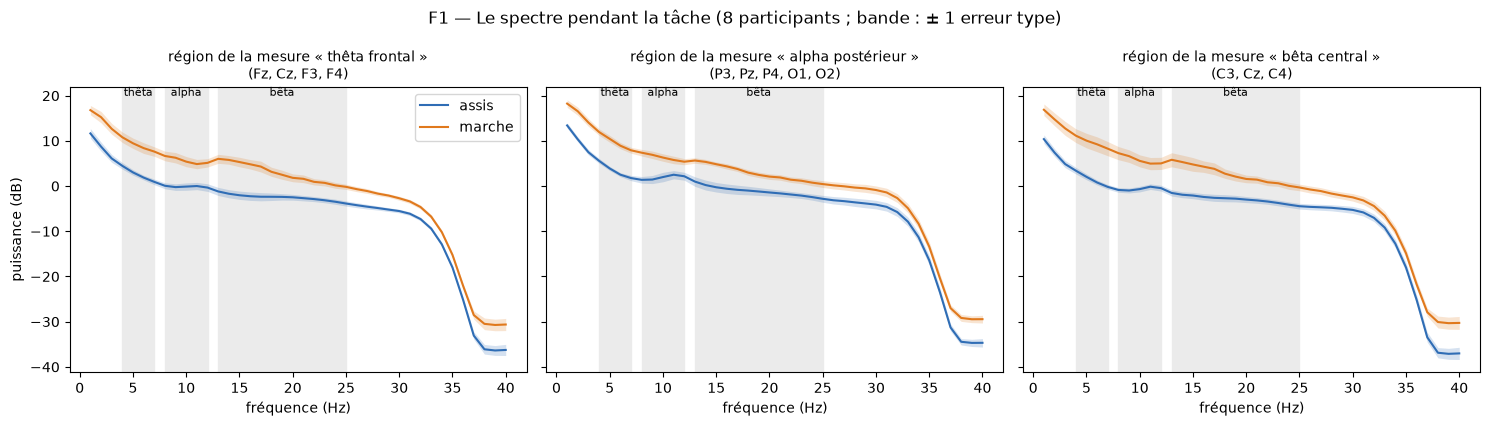

In [6]:
# ---- F1 : le spectre moyen du groupe, assis et en marche -------------------------------------------------------------------------
BANDES = {'thêta': (4, 7), 'alpha': (8, 12), 'bêta': (13, 25)}   # ne pas modifier : les bandes des trois mesures
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
for ax, (nom, m) in zip(axes, MESURES.items()):
    j = [noms_ch.index(c) for c in m['region']]              # les électrodes de la région de cette mesure
    for posture, couleur in (('assis', '#2f6db5'), ('marche', '#e0791d')):
        db_ = np.array([10 * np.log10(np.nanmean(spectres[(p, posture)][j], axis=0)) for p in deux_postures])   # participants x fréquences (dB)
        moyenne, erreur = db_.mean(axis=0), db_.std(axis=0, ddof=1) / np.sqrt(len(db_))   # la moyenne du groupe et son erreur type
        ax.plot(freqs_psd, moyenne, color=couleur, label=posture)
        ax.fill_between(freqs_psd, moyenne - erreur, moyenne + erreur, color=couleur, alpha=0.2, lw=0)
    ax.set_title(f'région de la mesure « {nom} »\n({", ".join(m["region"])})', fontsize=10)
    ax.set_xlabel('fréquence (Hz)')
axes[0].set_ylabel('puissance (dB)')
axes[0].legend()
for ax in axes:
    for bande, (f0, f1) in BANDES.items():                   # les trois bandes, en gris
        ax.axvspan(f0, f1, color='0.92', zorder=0)
        ax.text((f0 + f1) / 2, ax.get_ylim()[1], bande, ha='center', va='top', fontsize=8)
fig.suptitle(f'F1 — Le spectre pendant la tâche ({len(deux_postures)} participants ; bande : ± 1 erreur type)')
plt.tight_layout()
plt.show()

**Que regarder ? (F1)** Dans les trois régions, la courbe en marche est plus haute à toutes les fréquences, de 4 à 8 dB selon la
région et la bande : la puissance est multipliée par 2,5 à 6,6. Le cerveau ne travaille pas « plus fort » à toutes les fréquences à la fois :
cette hausse vient surtout du bruit de la marche (les électrodes sèches qui bougent à chaque pas, les muscles ; notebook 01). Assis, une
bosse se voit vers 10 Hz, surtout à l'arrière de la tête : c'est le rythme alpha. En marche, elle se distingue moins du fond. Au-delà de
30 Hz, les courbes plongent : c'est le filtre passe-bas du prétraitement, pas le cerveau.

In [7]:
# ---- 1.2 La puissance de votre bande : absolue et relative -----------------------------------------------------------------------
j = [noms_ch.index(c) for c in REGION]                       # les électrodes de votre région
dans_bande = (freqs_psd >= BANDE[0]) & (freqs_psd <= BANDE[1])
total = (freqs_psd >= 2) & (freqs_psd <= 30)                 # la puissance de 2 à 30 Hz, pour la puissance relative
lignes = []
for (participant, posture), s in spectres.items():
    lignes.append({'participant': participant, 'posture': posture,
                   'absolue (dB)': 10 * np.log10(np.nanmean(s[j][:, dans_bande])),   # la puissance de la bande, en dB
                   'relative (%)': 100 * np.nanmean(s[j][:, dans_bande].sum(axis=1) / s[j][:, total].sum(axis=1))})   # sa part du total
puissance = pd.DataFrame(lignes)
puissance.round(2)

,participant,posture,absolue (dB),relative (%)
0,P002,assis,-2.29,19.25
1,P002,marche,2.61,14.94
2,P003,assis,-3.88,22.42
3,P003,marche,7.16,30.99
4,P004,assis,-2.80,22.21
5,P004,marche,1.37,8.51
6,P005,marche,6.31,36.97
7,P006,assis,-2.42,17.62
8,P007,assis,-1.76,26.18
9,P007,marche,5.12,17.73


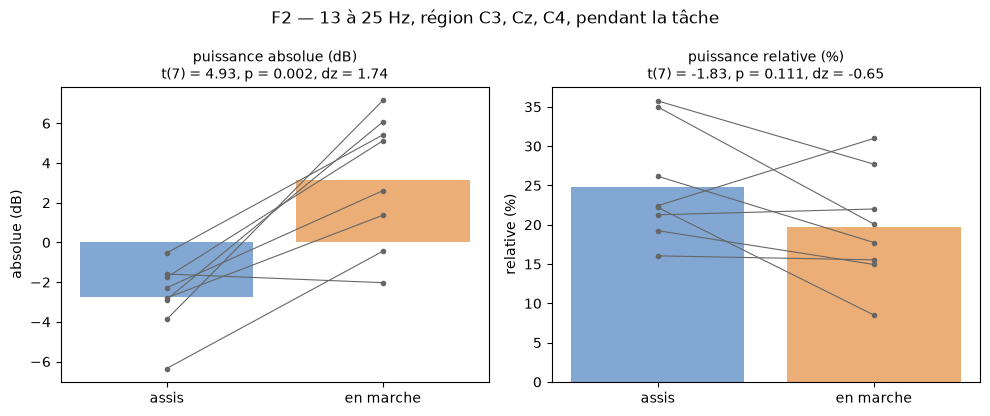

In [8]:
# ---- F2 : la puissance de votre bande, assis et en marche ------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, mesure in zip(axes, ['absolue (dB)', 'relative (%)']):
    large = puissance.pivot(index='participant', columns='posture', values=mesure).loc[deux_postures, ['assis', 'marche']]
    ax.bar([0, 1], large.mean(), color=['#2f6db5', '#e0791d'], alpha=0.6)
    for participant, valeurs in large.iterrows():
        ax.plot([0, 1], valeurs.to_numpy(), color='0.4', lw=0.8, marker='o', ms=3)   # un trait par participant
    t, p = stats.ttest_rel(large['marche'], large['assis'])  # test t apparié
    difference = large['marche'] - large['assis']
    dz = difference.mean() / difference.std(ddof=1)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['assis', 'en marche'])
    ax.set_ylabel(mesure)
    ax.set_title(f'puissance {mesure}\nt({len(large) - 1}) = {t:.2f}, p = {p:.3f}, dz = {dz:.2f}', fontsize=10)
    bilan[f'F2 puissance {mesure} ({BANDE[0]}-{BANDE[1]} Hz, {", ".join(REGION)}) : marche - assis'] = dict(
        n=len(large), difference_moyenne=round(difference.mean(), 2), t=round(t, 2), p=round(p, 4), dz=round(dz, 2))
fig.suptitle(f'F2 — {BANDE[0]} à {BANDE[1]} Hz, région {", ".join(REGION)}, pendant la tâche')
plt.tight_layout()
plt.show()

**Que regarder ? (F2)** À gauche, la puissance **absolue** : plus haute en marche chez presque tous les participants, à cause du bruit vu
dans F1. À droite, la puissance **relative**, la part de votre bande dans la puissance de 2 à 30 Hz : elle enlève la hausse commune à toutes
les fréquences et compare la forme des spectres. Pour le bêta central, elle baisse en marche chez 6 participants sur 8 (p = .11).
Plusieurs études trouvent moins d'alpha et de bêta en marchant qu'en restant debout (Seeber et al., 2014). Ici, la comparaison se fait avec
la position assise, et une partie du changement de forme peut venir du bruit, qui ajoute surtout de la puissance aux basses fréquences.

**Bloc Type 2.** Mettez `MESURE = 'alpha postérieur'` (cellule 0.4), puis `'thêta frontal'`, et relancez à partir de 0.4 : la puissance
relative de l'alpha baisse-t-elle plus nettement en marche ? Et celle du thêta, dans quel sens change-t-elle ?

## 2. Le temps-fréquence : la puissance après le mot (Bloc Type 1)

**Pourquoi ?** Le spectre de la section 1 résume toute l'époque. Pour voir *quand* la puissance change, on la calcule à chaque instant et pour
chaque fréquence : c'est une carte **temps-fréquence**.

**Comment ?** On compare le signal, autour de chaque instant, à une **ondelette de Morlet** : une oscillation de la fréquence voulue dans une
enveloppe en cloche. Plus l'ondelette a de cycles, plus la fréquence est précise, mais moins le temps l'est : c'est un compromis (Cohen,
2019). Ici, `N_CYCLES` vaut 3 cycles jusqu'à 6 Hz, puis la moitié de la fréquence (5 cycles à 10 Hz, 12,5 à 25 Hz). La puissance est calculée
dans chaque essai, puis moyennée : elle garde l'activité calée sur le mot et celle qui ne l'est pas.

**La ligne de base.** Chaque carte est divisée par la puissance moyenne de -0,5 à -0,2 s avant le mot, fréquence par fréquence, et passée en
dB : 0 dB veut dire « comme avant le mot ». Une hausse (en rouge) s'appelle une **synchronisation** (ERS), une baisse (en bleu) une
**désynchronisation** (ERD ; Pfurtscheller et Lopes da Silva, 1999).

**Les bords.** Près du début et de la fin de l'époque, l'ondelette déborde des données : les valeurs n'y sont pas fiables. Ces zones sont
en gris sur les cartes (le « cône d'influence », plus large pour les basses fréquences, dont l'ondelette est plus longue).

In [9]:
# ---- 2.1 La carte temps-fréquence de chaque participant, dans chaque condition ---------------------------------------------------
puissance_tf, db_tf, participants = {}, {}, []               # (participant, condition) -> électrodes x fréquences x temps
for participant, ep in epochs.items():
    e_a, e_b = ep[CHOIX_A], ep[CHOIX_B]                      # les époques des deux conditions
    if len(e_a) < MIN_EPOQUES or len(e_b) < MIN_EPOQUES:
        print(f'{participant} laissé de côté : {len(e_a)} essais {COND_A}, {len(e_b)} essais {COND_B}')
        continue
    for condition, e in ((COND_A, e_a), (COND_B, e_b)):
        mesuree = mesurees(e)                                # essais x électrodes
        p_ = np.full((len(e.ch_names), len(FREQUENCES), len(e.times)), np.nan)   # NaN : une électrode trop peu mesurée
        for k, c in enumerate(e.ch_names):                   # chaque électrode, sur les seuls essais où elle est mesurée
            if mesuree[:, k].sum() >= MIN_EPOQUES:
                tfr = e[np.flatnonzero(mesuree[:, k])].compute_tfr(method='morlet', freqs=FREQUENCES, n_cycles=N_CYCLES, picks=[c],
                                                                    average=True, return_itc=False)   # moyenne des essais
                p_[k] = tfr.data[0] * 1e12                   # en µV²
        puissance_tf[(participant, condition)] = p_
    participants.append(participant)
temps_tf = tfr.times                                         # les instants des cartes (s)
base = (temps_tf >= LIGNE_DE_BASE[0]) & (temps_tf <= LIGNE_DE_BASE[1])   # les instants de la ligne de base
for cle, p_ in puissance_tf.items():                         # en dB par rapport à la ligne de base, fréquence par fréquence
    db_tf[cle] = 10 * np.log10(p_ / p_[..., base].mean(axis=-1, keepdims=True))
print(f'{len(participants)} participants : {", ".join(participants)}')

P005 laissé de côté : 0 essais assis, 159 essais marche
P006 laissé de côté : 245 essais assis, 0 essais marche


8 participants : P002, P003, P004, P007, P008, P009, P010, P012


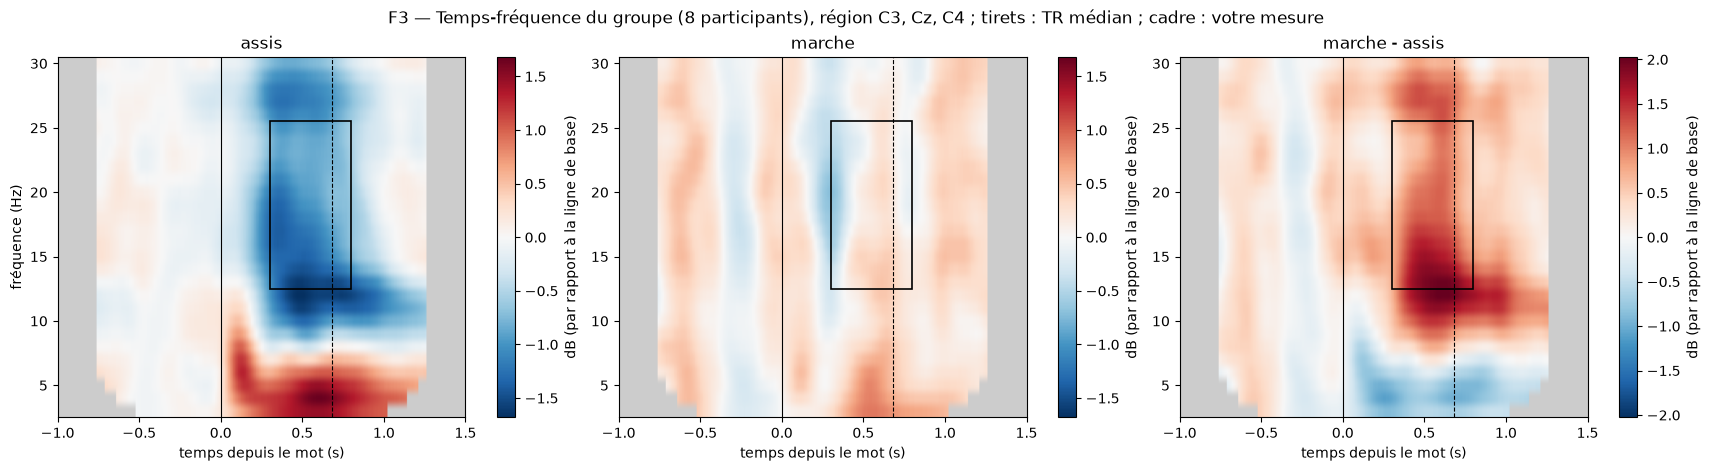

In [10]:
# ---- F3 : les cartes temps-fréquence du groupe, dans votre région ----------------------------------------------------------------
j = [noms_ch.index(c) for c in REGION]
carte = {c: np.mean([np.nanmean(db_tf[(p, c)][j], axis=0) for p in participants], axis=0) for c in (COND_A, COND_B)}   # fréquences x temps (dB)
sigma = N_CYCLES / (2 * np.pi * FREQUENCES)                  # l'écart-type de l'enveloppe de chaque ondelette (s)
bord = (temps_tf[None, :] < temps_tf[0] + 3 * sigma[:, None]) | (temps_tf[None, :] > temps_tf[-1] - 3 * sigma[:, None])   # le cône d'influence
tr_median = np.median(np.concatenate([epochs[p].metadata['tr_ms'].to_numpy() for p in participants])) / 1000   # le temps de réaction médian (s)
limite = max(np.abs(np.where(bord, 0, carte[COND_A])).max(), np.abs(np.where(bord, 0, carte[COND_B])).max())
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
panneaux = [(COND_A, carte[COND_A], limite), (COND_B, carte[COND_B], limite)]
panneaux.append((f'{COND_B} - {COND_A}', carte[COND_B] - carte[COND_A], np.abs(np.where(bord, 0, carte[COND_B] - carte[COND_A])).max()))
for ax, (titre, valeurs, lim) in zip(axes, panneaux):
    image = ax.imshow(np.where(bord, np.nan, valeurs), aspect='auto', origin='lower', cmap='RdBu_r', vmin=-lim, vmax=lim,
                      extent=[temps_tf[0], temps_tf[-1], FREQUENCES[0] - 0.5, FREQUENCES[-1] + 0.5])
    ax.set_facecolor('0.8')                                  # les bords non fiables restent gris
    ax.axvline(0, color='k', lw=0.8)                         # l'apparition du mot
    ax.axvline(tr_median, color='k', lw=0.8, ls='--')        # le temps de réaction médian
    ax.add_patch(plt.Rectangle((FENETRE[0], BANDE[0] - 0.5), FENETRE[1] - FENETRE[0], BANDE[1] - BANDE[0] + 1, fill=False, ec='k', lw=1.2))
    ax.set_title(titre)
    ax.set_xlabel('temps depuis le mot (s)')
    fig.colorbar(image, ax=ax, label='dB (par rapport à la ligne de base)')
axes[0].set_ylabel('fréquence (Hz)')
fig.suptitle(f'F3 — Temps-fréquence du groupe ({len(participants)} participants), région {", ".join(REGION)} ; '
             f'tirets : TR médian ; cadre : votre mesure')
plt.show()

**Que regarder ? (F3)** Assis, après le mot : une hausse des basses fréquences (3 à 7 Hz, en rouge), la plus forte autour du temps de
réaction (les tirets), et une baisse de l'alpha (8 à 12 Hz) et du bêta (13 à 30 Hz, en bleu), qui commence vers 200 ms. Au-dessus des
régions motrices, la baisse du bêta accompagne la préparation du mouvement : elle est la plus forte avant la tape. En marche, ces changements
sont bien plus faibles, et des bandes verticales traversent toutes les fréquences : la puissance y monte ou baisse partout à la fois, comme
le bruit de F1. La carte de droite montre la différence : en marche, l'alpha et le bêta baissent moins, et le thêta monte moins.

### 2.2 La ligne de base n'est pas la même dans les deux conditions (Bloc Type 1)

Un changement en dB est un **rapport** : la puissance après le mot divisée par celle d'avant. Si une condition ajoute du bruit qui ne change
pas après le mot, ce bruit grossit les deux termes du rapport, et le rapport se rapproche de 1 (0 dB) : le changement paraît plus petit,
sans que le cerveau change moins. C'est le cas de la marche (section 1). Comparer des dB entre deux conditions dont la puissance diffère déjà
avant le stimulus demande donc de la prudence (Gyurkovics et al., 2021 ; Keil et al., 2022).

La cellule compare, pour votre mesure : la puissance avant le mot, le changement en dB et le changement en µV² (après moins avant, sans
rapport). Si la différence entre les conditions disparaît en µV², elle vient peut-être surtout de la ligne de base.

In [11]:
# ---- 2.2 Avant le mot, et le même changement en dB et en µV² ---------------------------------------------------------------------
j = [noms_ch.index(c) for c in REGION]
dans_bande = (FREQUENCES >= BANDE[0]) & (FREQUENCES <= BANDE[1])
dans_fenetre = (temps_tf >= FENETRE[0]) & (temps_tf <= FENETRE[1])
lignes = []
for participant in participants:
    for condition in (COND_A, COND_B):
        p_ = puissance_tf[(participant, condition)][j][:, dans_bande]   # électrodes x fréquences x temps (µV²)
        avant, apres = np.nanmean(p_[:, :, base]), np.nanmean(p_[:, :, dans_fenetre])   # la moyenne des électrodes mesurées
        lignes.append({'participant': participant, 'condition': condition, 'avant le mot (dB)': 10 * np.log10(avant),
                       'changement (dB)': np.nanmean(db_tf[(participant, condition)][j][:, dans_bande][:, :, dans_fenetre]),
                       'changement (µV²)': apres - avant})
comparaison = pd.DataFrame(lignes)
for colonne in ('avant le mot (dB)', 'changement (dB)', 'changement (µV²)'):
    large = comparaison.pivot(index='participant', columns='condition', values=colonne)
    t, p = stats.ttest_rel(large[COND_B], large[COND_A])
    print(f'{colonne:18s} : {COND_A} {large[COND_A].mean():+8.2f}, {COND_B} {large[COND_B].mean():+8.2f} ; '
          f'{COND_B} - {COND_A} = {(large[COND_B] - large[COND_A]).mean():+.2f} (t({len(large) - 1}) = {t:.2f}, p = {p:.3f})')
    bilan[f'2.2 {NOM}, {colonne}'] = dict(n=len(large), difference_moyenne=round((large[COND_B] - large[COND_A]).mean(), 2),
                                          t=round(t, 2), p=round(p, 4))

avant le mot (dB)  : assis   +17.66, marche   +22.91 ; marche - assis = +5.25 (t(7) = 4.44, p = 0.003)
changement (dB)    : assis    -1.03, marche    +0.03 ; marche - assis = +1.06 (t(7) = 2.98, p = 0.021)
changement (µV²)   : assis   -15.85, marche    +8.27 ; marche - assis = +24.12 (t(7) = 2.73, p = 0.029)


**Que regarder ? (2.2)** Avant le mot, la puissance du bêta central est plus haute de 5,3 dB en marche (p = .003) : la ligne de base
n'est pas la même. En dB, la baisse du bêta est plus petite en marche (+1,06 dB, p = .021). En µV², la différence va dans le même sens
(+24 µV², p = .029) : pour le bêta central, la conclusion ne dépend pas de la mesure. Avec `MESURE = 'thêta frontal'`, c'est différent :
la hausse du thêta est plus petite en marche en dB (-0,77 dB, p = .045), mais la différence disparaît en µV² (p = .43). Une partie de la
différence en dB peut alors venir du bruit qui gonfle la ligne de base en marche. Aucune des deux mesures n'est « la bonne » : Keil et al.
(2022) conseillent de vérifier un résultat avec et sans la correction par la ligne de base.

### 2.3 Évoqué ou induit ? (Bloc Type 3)

La carte de F3 mélange deux activités : celle qui est **calée** sur le mot, au même instant et avec la même phase dans chaque essai (c'est
elle qui fait l'ERP du notebook 09), et celle qui ne l'est pas, dite **induite**. Si on retire l'ERP de chaque essai avant le calcul, il ne
reste que la partie induite. La cellule compare, dans la condition A, le changement total et le changement induit pour votre mesure.

In [12]:
# ---- 2.3 (Bloc Type 3) Le changement total et le changement induit, condition A --------------------------------------------------
lignes = []
for participant in participants:
    e = epochs[participant][CHOIX_A]
    mesuree = mesurees(e)
    induit_db = []                                           # le changement induit de chaque électrode mesurée de la région (dB)
    for k in j:                                              # les électrodes de votre région
        if mesuree[:, k].sum() < MIN_EPOQUES:
            continue
        e_k = e[np.flatnonzero(mesuree[:, k])].copy().pick([e.ch_names[k]]).subtract_evoked()   # chaque essai moins l'ERP : il reste l'activité non calée
        p_ = e_k.compute_tfr(method='morlet', freqs=FREQUENCES, n_cycles=N_CYCLES, average=True, return_itc=False).data[0] * 1e12
        induit_db.append(10 * np.log10(p_ / p_[:, base].mean(axis=-1, keepdims=True))[dans_bande][:, dans_fenetre].mean())
    lignes.append({'participant': participant,
                   'total (dB)': np.nanmean(db_tf[(participant, COND_A)][j][:, dans_bande][:, :, dans_fenetre]),
                   'induit (dB)': np.mean(induit_db)})
induit = pd.DataFrame(lignes).set_index('participant')
print(f'{COND_A}, {NOM} : total {induit["total (dB)"].mean():+.2f} dB, induit {induit["induit (dB)"].mean():+.2f} dB (moyenne du groupe)')
induit.round(2)

assis, bêta central : total -1.03 dB, induit -1.03 dB (moyenne du groupe)


,total (dB),induit (dB)
participant,,
P002,-0.18,-0.17
P003,-0.50,-0.49
P004,-2.05,-2.07
P007,-0.17,-0.18
P008,-3.05,-3.06
P009,-0.31,-0.31
P010,-0.39,-0.39
P012,-1.61,-1.61


**Que regarder ? (2.3)** Pour le bêta central, le changement induit (-1,03 dB) est égal au changement total (-1,03 dB) : la baisse du
bêta n'est pas calée en phase sur le mot, et l'ERP du notebook 09 ne peut pas la montrer. Avec `MESURE = 'thêta frontal'`, une partie de
la hausse est calée sur le mot (total +1,14 dB, induit +0,94 dB) : elle appartient aux ondes lentes de l'ERP.

## 3. Une mesure par participant (Bloc Type 1)

Pour chaque participant et chaque condition, on prend la moyenne de sa carte temps-fréquence (en dB) dans le cadre de F3 : votre bande,
votre fenêtre et votre région. Puis on compare les deux conditions avec un test t apparié, une seule fois : c'est le test principal de votre
hypothèse.

In [13]:
# ---- 3.1 Le changement de puissance de chaque participant ------------------------------------------------------------------------
lignes = []
for participant in participants:
    for condition in (COND_A, COND_B):
        lignes.append({'participant': participant, 'condition': condition,
                       'changement (dB)': np.nanmean(db_tf[(participant, condition)][j][:, dans_bande][:, :, dans_fenetre])})
mesures_tf = pd.DataFrame(lignes)
mesures_tf.pivot(index='participant', columns='condition', values='changement (dB)')[[COND_A, COND_B]].round(2)

condition,assis,marche
participant,,
P002,-0.18,-0.28
P003,-0.50,0.37
P004,-2.05,-0.18
P007,-0.17,0.29
P008,-3.05,-0.10
P009,-0.31,-0.03
P010,-0.39,0.19
P012,-1.61,-0.06


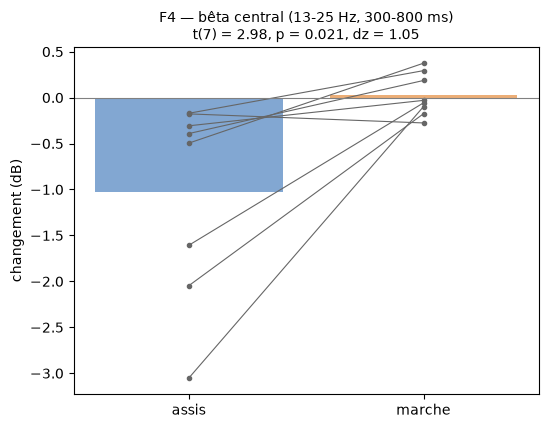

assis : -1.03 dB par rapport à la ligne de base, t(7) = -2.70, p = 0.030
marche : +0.03 dB par rapport à la ligne de base, t(7) = 0.34, p = 0.747


In [14]:
# ---- F4 : le changement de puissance, condition par condition --------------------------------------------------------------------
large = mesures_tf.pivot(index='participant', columns='condition', values='changement (dB)')[[COND_A, COND_B]]
t, p = stats.ttest_rel(large[COND_B], large[COND_A])
difference = large[COND_B] - large[COND_A]
dz = difference.mean() / difference.std(ddof=1)
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar([0, 1], large.mean(), color=[COULEURS[COND_A], COULEURS[COND_B]], alpha=0.6)
for participant, valeurs in large.iterrows():
    ax.plot([0, 1], valeurs.to_numpy(), color='0.4', lw=0.8, marker='o', ms=3)
ax.axhline(0, color='0.5', lw=0.8)                           # 0 dB : comme avant le mot
ax.set_xticks([0, 1])
ax.set_xticklabels([COND_A, COND_B])
ax.set_ylabel('changement (dB)')
ax.set_title(f'F4 — {NOM} ({BANDE[0]}-{BANDE[1]} Hz, {FENETRE[0] * 1000:.0f}-{FENETRE[1] * 1000:.0f} ms)\n'
             f't({len(large) - 1}) = {t:.2f}, p = {p:.3f}, dz = {dz:.2f}', fontsize=10)
plt.show()
for condition in (COND_A, COND_B):                           # chaque changement contre 0 dB
    t0_, p0_ = stats.ttest_1samp(large[condition], 0.0)
    print(f'{condition} : {large[condition].mean():+.2f} dB par rapport à la ligne de base, t({len(large) - 1}) = {t0_:.2f}, p = {p0_:.3f}')
bilan[f'F4 {NOM} : {COND_B} - {COND_A}'] = dict(n=len(large), difference_moyenne=round(difference.mean(), 2), t=round(t, 2), p=round(p, 4),
                                                dz=round(dz, 2))

**Que regarder ? (F4)** Assis, le bêta central baisse chez les 8 participants (-1,03 dB en moyenne ; p = .030 contre 0, dans la sortie). En
marche, il ne baisse plus (+0,03 dB). La différence (p = .021) va dans le même sens chez 7 participants sur 8. Souvenez-vous de 2.2 :
en marche, la ligne de base est plus haute ; pour le bêta central, la différence tient aussi en µV².

**Bloc Type 2.** Refaites les sections 2 à 4 avec les trois mesures (`MESURE`) et les trois hypothèses (`HYPOTHESE`), et notez les
résultats dans un tableau. Pour la fréquence et la lexicalité, essayez aussi `POSTURE = 'assis'` : le bruit de la marche n'y entre plus.

## 4. Les topographies (Bloc Type 1)

La même mesure (votre bande, dans votre fenêtre) à chaque électrode, vue de dessus (le nez en haut). Les trois premières cartes ont la même
échelle ; la dernière donne le t du test apparié à chaque électrode (ronds blancs : p < .05, sans correction : un test par électrode, tous faits en même
temps).

Comme dans le notebook 09, une électrode n'a de valeur chez un participant que si elle a été mesurée dans au moins 20 essais de chaque
condition, et la carte du groupe ne montre que les électrodes mesurées chez au moins 3 participants et la moitié d'entre eux (les autres
sont des cercles vides).

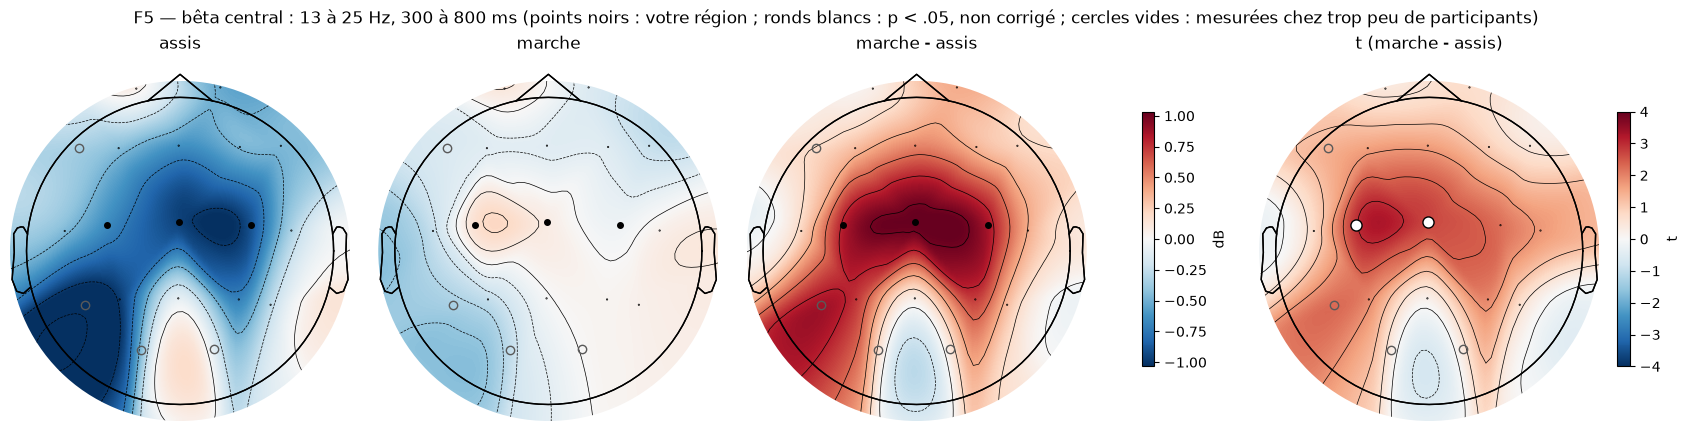

Électrodes à p < .05 : ['C3', 'Cz']
Le nombre de participants qui ont mesuré chaque électrode : {'Fp1': 5, 'Fp2': 5, 'F7': 3, 'F3': 7, 'Fz': 8, 'F4': 7, 'F8': 5, 'T7': 6, 'C3': 5, 'Cz': 8, 'C4': 7, 'T8': 7, 'P7': 0, 'P3': 7, 'Pz': 6, 'P4': 8, 'P8': 6, 'O1': 2, 'O2': 2}


In [15]:
# ---- F5 : les cartes des deux conditions, de leur différence, et le t par électrode ----------------------------------------------
from matplotlib.colors import ListedColormap                 # une carte de couleurs transparente, pour les cercles vides
valeurs = {c: np.array([db_tf[(p, c)][:, dans_bande][:, :, dans_fenetre].mean(axis=(1, 2)) for p in participants])
           for c in (COND_A, COND_B)}                       # participants x électrodes (NaN : pas mesurée)
deux = np.isfinite(valeurs[COND_A]) & np.isfinite(valeurs[COND_B])   # le participant a mesuré l'électrode dans les deux conditions
n_mesure = deux.sum(axis=0)                                  # le nombre de participants qui l'ont mesurée
vue = n_mesure >= max(3, len(participants) / 2)              # la règle du projet : au moins 3 participants, et la moitié d'entre eux
t_el, p_el = np.full(len(noms_ch), np.nan), np.full(len(noms_ch), np.nan)
for k in np.flatnonzero(vue):                                # un test t apparié par électrode, chez les participants qui l'ont mesurée
    t_el[k], p_el[k] = stats.ttest_rel(valeurs[COND_B][deux[:, k], k], valeurs[COND_A][deux[:, k], k])
cartes = [np.array([v[deux[:, k], k].mean() if vue[k] else np.nan for k in range(len(noms_ch))])
          for v in (valeurs[COND_A], valeurs[COND_B], valeurs[COND_B] - valeurs[COND_A])]   # la moyenne des participants qui l'ont mesurée
limite = max(np.nanmax(np.abs(c)) for c in cartes)
info = epochs[participants[0]].info
info_vue = mne.pick_info(info, np.flatnonzero(vue))
vides = dict(sensors=False, contours=0, mask=~vue, mask_params=dict(marker='o', markerfacecolor='none', markeredgecolor='0.35', markersize=6))
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), constrained_layout=True)
for ax, c, titre in zip(axes[:3], cartes, [COND_A, COND_B, f'{COND_B} - {COND_A}']):
    image, _ = mne.viz.plot_topomap(c[vue], info_vue, axes=ax, show=False, vlim=(-limite, limite), cmap='RdBu_r',
                                    mask=np.isin(np.array(noms_ch)[vue], REGION), mask_params=dict(marker='o', markerfacecolor='k', markersize=4))
    ax.set_title(titre)
fig.colorbar(image, ax=axes[:3], shrink=0.7, label='dB')
image_t, _ = mne.viz.plot_topomap(t_el[vue], info_vue, axes=axes[3], show=False, vlim=(-4, 4), cmap='RdBu_r', mask=p_el[vue] < 0.05,
                                  mask_params=dict(marker='o', markerfacecolor='w', markeredgecolor='k', markersize=8))
if not vue.all():                                            # les électrodes trop peu mesurées : des cercles vides, sans valeur
    for ax in axes:
        mne.viz.plot_topomap(np.zeros(len(noms_ch)), info, axes=ax, show=False, vlim=(-1, 1), cmap=ListedColormap([(0, 0, 0, 0)]), **vides)
axes[3].set_title(f't ({COND_B} - {COND_A})')
fig.colorbar(image_t, ax=axes[3], shrink=0.7, label='t')
fig.suptitle(f'F5 — {NOM} : {BANDE[0]} à {BANDE[1]} Hz, {FENETRE[0] * 1000:.0f} à {FENETRE[1] * 1000:.0f} ms '
             f'(points noirs : votre région ; ronds blancs : p < .05, non corrigé ; cercles vides : mesurées chez trop peu de participants)')
plt.show()
significatives = [c for c, p_ in zip(noms_ch, p_el) if p_ < 0.05]
bilan[f'F5 électrodes à p < .05 ({NOM})'] = dict(n=len(participants), electrodes=', '.join(significatives) or 'aucune')
print('Électrodes à p < .05 :', significatives or 'aucune')
print('Le nombre de participants qui ont mesuré chaque électrode :', dict(zip(noms_ch, n_mesure.tolist())))

**Que regarder ? (F5)** Assis, la baisse du bêta se trouve au-dessus des deux régions motrices et du centre (autour de C3, Cz et C4) :
c'est la préparation de la tape. La grande tache bleue en bas à gauche entoure des cercles vides (P7, O1) : là, la couleur vient de
l'interpolation de l'affichage, pas d'une mesure. En marche, la carte est presque plate. La différence est la plus forte au centre ; elle
est significative à C3 et Cz, sans correction pour les tests faits en même temps. O1 et O2 (mesurées chez 2 participants seulement), F7 (3)
et P7 (aucun) n'ont pas de valeur : ce sont les cercles vides.

## 5. Sans la tâche : le repos et la marche seule (Bloc Type 3)

**Pourquoi ?** La séance contient aussi des enregistrements sans tâche : un repos assis au début et un autre à la fin (5 minutes, yeux
ouverts sur une croix), et la marche seule sur le tapis (5 minutes, avant les blocs en marche). Ils ne servent pas de ligne de base aux ERP,
qui reste la période juste avant le mot (notebook 09). Ils servent de **références pour les rythmes**, pour trois questions que les blocs
de la tâche ne peuvent pas trancher seuls :

1. **Posture × tâche (5.2).** Avec eux, on a quatre cellules : assis sans tâche (le repos), assis avec la tâche, en marche sans tâche (la
   marche seule) et en marche avec la tâche. La comparaison de la section 1 (assis contre en marche, pendant la tâche) mélange ce que la
   marche ajoute au signal, cerveau et bruit compris, et ce que la tâche y change. Les quatre cellules les séparent.
2. **Le cycle de la marche (5.3).** La puissance suit-elle le pas ? La tâche change-t-elle cela ?
3. **Le début et la fin de la séance (5.4).** Le repos est-il le même au début et à la fin ?

**Les fichiers** (`pretraite/continus/`, un par participant et enregistrement) : les enregistrements nettoyés par le même pipeline, en
continu, à 100 Hz. Les annotations marquent les moments inutilisables (`BAD_span`) et chaque contact du talon (`talon/droit`,
`talon/gauche`), mesuré par les plaques de force du tapis ou, à défaut, par l'accéléromètre du casque. `enregistrements.tsv` donne les
électrodes reconstruites de chaque enregistrement et l'ordre de la séance (blocs assis d'abord, ou blocs en marche d'abord).

In [16]:
# ---- 5.1 (Bloc Type 3) Charger les enregistrements continus ----------------------------------------------------------------------
dossier_continus = DOSSIER / 'pretraite' / 'continus'
if not (dossier_continus / 'enregistrements.tsv').exists():
    raise ValueError('Les enregistrements continus (pretraite/continus/) sont introuvables : relancez la cellule 0.1, elle télécharge la dernière version des données')
enregistrements = pd.read_csv(dossier_continus / 'enregistrements.tsv', sep='\t', keep_default_na=False)   # une ligne par enregistrement
continus = {}                                                # (participant, enregistrement) -> l'enregistrement continu
for ligne in enregistrements.itertuples():
    fichier = dossier_continus / f'sub-{ligne.participant}_{ligne.enregistrement}_eeg.fif'
    continus[(ligne.participant, ligne.enregistrement)] = mne.io.read_raw_fif(fichier, preload=True)
ORDRE_ENR = ['repos_debut', 'repos_fin', 'marche_seule', 'marche_bloc1', 'marche_bloc2', 'marche_bloc3', 'marche_bloc4']
print(f'{len(continus)} enregistrements continus ; la durée de chacun (s) :')
enregistrements.pivot_table(index=['participant', 'ordre'], columns='enregistrement', values='duree_s').reindex(columns=ORDRE_ENR)

67 enregistrements continus ; la durée de chacun (s) :


,enregistrement,repos_debut,repos_fin,marche_seule,marche_bloc1,marche_bloc2,marche_bloc3,marche_bloc4
participant,ordre,,,,,,,
P002,marche d'abord,308.0,310.0,324.0,282.0,262.0,254.0,266.0
P003,assis d'abord,306.0,302.0,308.0,260.0,258.0,250.0,256.0
P004,assis d'abord,270.0,304.0,322.0,260.0,270.0,260.0,254.0
P005,marche d'abord,306.0,NaN,388.0,292.0,278.0,NaN,NaN
P006,marche d'abord,310.0,304.0,334.0,262.0,260.0,234.0,258.0
P007,assis d'abord,304.0,332.0,306.0,260.0,260.0,256.0,278.0
P008,assis d'abord,362.0,214.0,222.0,202.0,246.0,230.0,244.0
P009,marche d'abord,304.0,304.0,316.0,262.0,260.0,252.0,262.0
P010,marche d'abord,306.0,314.0,384.0,260.0,238.0,218.0,258.0


### 5.2 Posture × tâche : les quatre cellules (Bloc Type 3)

**Comment ?** Les enregistrements sans tâche sont coupés en fenêtres de 2,5 s, la longueur des époques longues, avec des règles proches
de celles des époques : une fenêtre qui touche un moment `BAD_span` est laissée de côté. Dans une fenêtre, une électrode mesurée qui dépasse
±100 µV, une fois sa tendance linéaire retirée, est mise de côté pour cette fenêtre seulement, comme une électrode reconstruite dans une
époque. Comme dans le pipeline, une fenêtre perd au plus 3 électrodes ; au-delà, elle est laissée de côté. Le spectre est calculé comme en
section 1 (Welch, morceaux de 1 s) : pour chaque électrode, la moyenne des fenêtres où elle est mesurée. La marche seule ne garde que la
marche, du premier au dernier contact du talon (chez P010 et P012, l'enregistrement commence avant la marche ou continue après). Les deux
cellules avec la tâche sont les spectres de la section 1.

**Quel repos ?** Celui qui est voisin des blocs assis : le repos du début si les blocs assis viennent en premier, celui de la fin sinon. Le
repos et les blocs assis sont alors proches dans le temps, comme la marche seule et les blocs en marche.

**Les comparaisons**, pour votre mesure (bande et région de la cellule 0.4 ; une électrode n'entre que si elle a une valeur dans les quatre
cellules) :

| Comparaison | Question |
|---|---|
| tâche assis - repos | que change la tâche, assis ? |
| tâche en marche - marche seule | que change la tâche, en marche ? |
| marche seule - repos | que change la marche, sans tâche ? |
| interaction : (tâche en marche - marche seule) - (tâche assis - repos) | la tâche change-t-elle autre chose en marche qu'assis ? |

Chacune est donnée en dB (un rapport, comme en 2.2) et en µV²/Hz (une soustraction). Le bruit de la marche est dans les deux termes de
« tâche en marche - marche seule » : une soustraction l'enlève s'il est le même dans les deux, un rapport l'écrase vers 0 dB.

In [17]:
# ---- 5.2 (Bloc Type 3) Les spectres des quatre cellules, et les comparaisons -----------------------------------------------------
from scipy.signal import detrend                             # retire la tendance linéaire d'un signal
DUREE = exemple.times[-1] - exemple.times[0]                 # ne pas modifier : la longueur des époques longues (2,5 s)
SEUIL_UV = 100.0                                             # ne pas modifier : la règle des époques longues (±100 µV, tendance retirée)
MAX_MISES_DE_COTE = 3                                        # ne pas modifier : comme le pipeline, au plus 3 électrodes par fenêtre


def spectre_sans_tache(raw, reconstruites, marche=False):
    """Électrodes x fréquences (µV²/Hz ; NaN : électrode trop peu mesurée) : pour chaque électrode, le spectre moyen des fenêtres où elle
    est mesurée ; et le nombre de fenêtres gardées et coupées. marche=True : seulement du premier au dernier contact du talon."""
    if marche:
        talons = np.array([a['onset'] for a in raw.annotations if a['description'].startswith('talon')])   # les contacts du talon (s)
        raw = raw.copy().crop(talons.min(), talons.max())
    fenetres = mne.make_fixed_length_epochs(raw, duration=DUREE, reject_by_annotation=True, preload=True)   # sans les moments BAD
    mesuree = np.array([c not in reconstruites.split() for c in raw.ch_names])   # les électrodes mesurées dans l'enregistrement
    depasse = np.abs(detrend(fenetres.get_data(units='uV'), axis=-1)).max(axis=-1) > SEUIL_UV   # fenêtres x électrodes
    garde = (depasse & mesuree).sum(axis=1) <= MAX_MISES_DE_COTE   # les fenêtres qui perdent au plus 3 électrodes mesurées
    ok = (mesuree & ~depasse)[garde]                         # fenêtres gardées x électrodes : mesurée et sous ±100 µV ?
    psd = fenetres[np.flatnonzero(garde)].compute_psd(method='welch', fmin=1.0, fmax=40.0, n_fft=100, n_per_seg=100, n_overlap=50)
    compte = ok.sum(axis=0)                                  # le nombre de fenêtres où chaque électrode compte
    s = np.where(ok[:, :, None], psd.get_data(), 0.0).sum(axis=0) / np.maximum(compte, 1)[:, None] * 1e12   # comme en 1.1
    s[compte < MIN_EPOQUES] = np.nan
    return s, int(garde.sum()), len(fenetres)


CELLULES = ['repos', 'tâche assis', 'marche seule', 'tâche en marche']
cellules, lignes = {}, []                                    # (participant, cellule) -> électrodes x fréquences (µV²/Hz)
for participant in deux_postures:                            # les participants qui ont les époques des deux postures (section 1)
    infos = enregistrements[enregistrements['participant'] == participant].set_index('enregistrement')
    repos = 'repos_debut' if infos['ordre'].iloc[0] == "assis d'abord" else 'repos_fin'   # le repos voisin des blocs assis
    if repos not in infos.index or 'marche_seule' not in infos.index:
        continue
    for cellule, nom in (('repos', repos), ('marche seule', 'marche_seule')):
        s, n_garde, n_total = spectre_sans_tache(continus[(participant, nom)], infos.loc[nom, 'reconstruites'], marche=(cellule == 'marche seule'))
        if n_garde >= MIN_EPOQUES:
            cellules[(participant, cellule)] = s
        lignes.append({'participant': participant, 'cellule': cellule, 'enregistrement': nom, 'fenêtres gardées': n_garde,
                       'fenêtres': n_total})
    cellules[(participant, 'tâche assis')] = spectres[(participant, 'assis')]
    cellules[(participant, 'tâche en marche')] = spectres[(participant, 'marche')]
quatre = [p for p in deux_postures if all((p, c) in cellules for c in CELLULES)]   # les participants qui ont les quatre cellules
print(f'{len(quatre)} participants avec les quatre cellules : {", ".join(quatre)}')
print(pd.DataFrame(lignes).pivot(index='participant', columns='cellule', values='fenêtres gardées').to_string())

j = [noms_ch.index(c) for c in REGION]
dans_bande = (freqs_psd >= BANDE[0]) & (freqs_psd <= BANDE[1])
valeurs_4 = []                                               # la puissance de votre bande dans chaque cellule (µV²/Hz)
for participant in quatre:
    commun = [k for k in j if all(np.isfinite(cellules[(participant, c)][k]).all() for c in CELLULES)]   # une valeur dans les 4 cellules
    if not commun:
        continue                                             # aucune électrode de votre région n'a les quatre cellules
    valeurs_4.append({c: cellules[(participant, c)][commun][:, dans_bande].mean() for c in CELLULES} | {'participant': participant})
valeurs_4 = pd.DataFrame(valeurs_4).set_index('participant')[CELLULES]
COMPARAISONS = {'tâche assis - repos': ('tâche assis', 'repos'), 'tâche en marche - marche seule': ('tâche en marche', 'marche seule'),
                'marche seule - repos': ('marche seule', 'repos')}
for unite, v in (('dB', 10 * np.log10(valeurs_4)), ('µV²/Hz', valeurs_4)):
    differences = {nom: v[a] - v[b] for nom, (a, b) in COMPARAISONS.items()}
    differences['interaction'] = differences['tâche en marche - marche seule'] - differences['tâche assis - repos']
    for nom, d in differences.items():
        t, p = stats.ttest_1samp(d, 0.0)
        print(f'{nom:31s} {d.mean():+9.2f} {unite:6s} t({len(d) - 1}) = {t:5.2f}, p = {p:.3f} ; {int((d > 0).sum())} sur {len(d)} au-dessus de 0')
        bilan[f'5.2 {NOM}, {nom} ({unite})'] = dict(n=len(d), difference_moyenne=round(d.mean(), 2), t=round(t, 2), p=round(p, 4))
(10 * np.log10(valeurs_4)).round(2)                          # votre mesure dans chaque cellule (dB)

8 participants avec les quatre cellules : P002, P003, P004, P007, P008, P009, P010, P012
cellule      marche seule  repos
participant                     
P002                  107    119
P003                  114    120
P004                  116     99
P007                  116    119
P008                   80    117
P009                  118    119
P010                  119    123
P012                  117    121
tâche assis - repos                 -0.58 dB     t(7) = -0.94, p = 0.380 ; 4 sur 8 au-dessus de 0
tâche en marche - marche seule      +0.20 dB     t(7) =  0.29, p = 0.777 ; 3 sur 8 au-dessus de 0
marche seule - repos                +5.04 dB     t(7) =  3.40, p = 0.012 ; 7 sur 8 au-dessus de 0
interaction                         +0.78 dB     t(7) =  0.94, p = 0.380 ; 4 sur 8 au-dessus de 0
tâche assis - repos                 -0.06 µV²/Hz t(7) = -0.95, p = 0.373 ; 4 sur 8 au-dessus de 0
tâche en marche - marche seule      +0.01 µV²/Hz t(7) =  0.04, p = 0.967 ; 3 sur 8 au-dessu

,repos,tâche assis,marche seule,tâche en marche
participant,,,,
P002,-3.11,-2.29,3.48,2.61
P003,-3.90,-3.88,7.36,7.16
P004,-1.19,-2.80,3.57,1.37
P007,-2.71,-1.76,6.11,5.12
P008,0.03,-0.48,4.57,4.66
P009,-2.47,-2.88,2.62,6.08
P010,-1.96,-6.35,-0.13,-0.44
P012,-2.08,-1.59,-4.61,-2.03


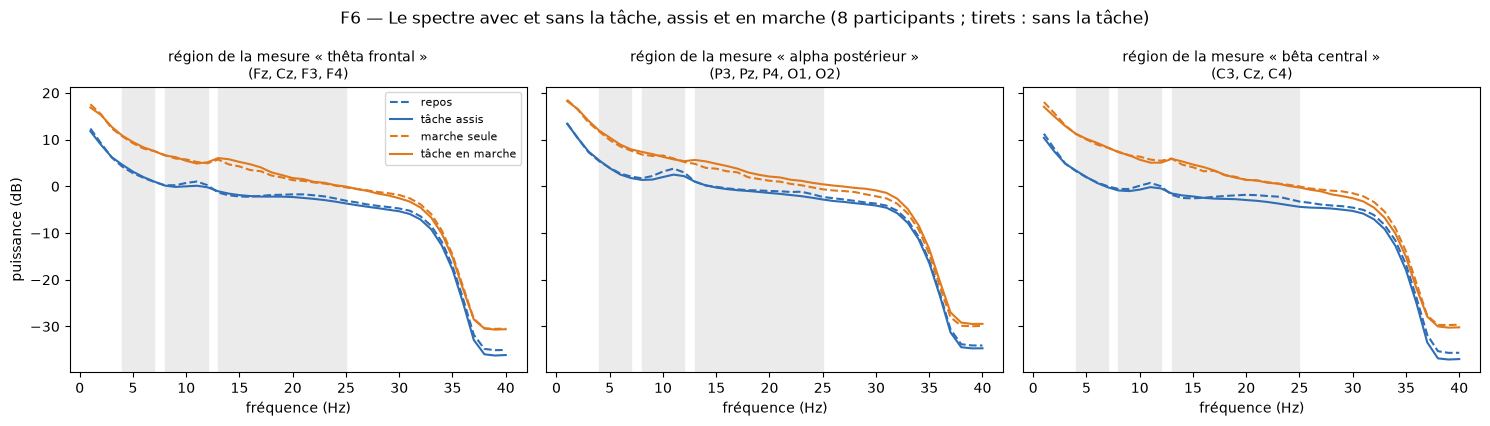

In [18]:
# ---- F6 (Bloc Type 3) Le spectre des quatre cellules -----------------------------------------------------------------------------
STYLE = {'repos': ('#2f6db5', '--'), 'tâche assis': ('#2f6db5', '-'), 'marche seule': ('#e0791d', '--'), 'tâche en marche': ('#e0791d', '-')}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
for ax, (nom, m) in zip(axes, MESURES.items()):
    for cellule in CELLULES:
        db_ = []
        for p in quatre:                                     # les électrodes de la région qui ont une valeur dans les quatre cellules
            k = [noms_ch.index(c) for c in m['region'] if all(np.isfinite(cellules[(p, x)][noms_ch.index(c)]).all() for x in CELLULES)]
            if k:
                db_.append(10 * np.log10(cellules[(p, cellule)][k].mean(axis=0)))
        couleur, trait = STYLE[cellule]
        ax.plot(freqs_psd, np.mean(db_, axis=0), color=couleur, ls=trait, label=cellule)
    ax.set_title(f'région de la mesure « {nom} »\n({", ".join(m["region"])})', fontsize=10)
    ax.set_xlabel('fréquence (Hz)')
    for bande, (f0, f1) in BANDES.items():
        ax.axvspan(f0, f1, color='0.92', zorder=0)
axes[0].set_ylabel('puissance (dB)')
axes[0].legend(fontsize=8)
fig.suptitle(f'F6 — Le spectre avec et sans la tâche, assis et en marche ({len(quatre)} participants ; tirets : sans la tâche)')
plt.tight_layout()
plt.show()

**Que regarder ? (F6 et 5.2)** Dans les trois régions, les deux courbes en marche (orange) sont de 3 à 8 dB au-dessus des deux courbes
assises (bleu), avec ou sans la tâche. Assis, la bosse de l'alpha vers 10 Hz est plus haute au repos que pendant la tâche, surtout à
l'arrière de la tête. En marche, la courbe avec la tâche et celle sans la tâche se superposent presque.

Pour le bêta central, la marche seule dépasse le repos de 5,0 dB (p = .012, chez 7 participants sur 8). La tâche ne change presque rien,
ni assis (-0,58 dB, p = .38) ni en marche (+0,20 dB, p = .78), et l'interaction n'est pas significative (+0,78 dB, p = .38 ; en µV²/Hz,
p = .83). La hausse de puissance en marche vue en section 1 est donc déjà là sans la tâche : elle vient de la marche elle-même (le cerveau
et le bruit), pas de la tâche faite en marchant.

Avec `MESURE = 'alpha postérieur'`, assis, l'alpha est plus bas pendant la tâche qu'au repos (-1,05 dB, p = .065 ; -0,59 µV²/Hz,
p = .024) : regarder et lire des mots baisse l'alpha. En marche, cette baisse disparaît (+0,06 dB, p = .80), et l'interaction est à la
limite (+1,10 dB, p = .099 ; +0,72 µV²/Hz, p = .049). Avec 8 participants et plusieurs tests sans correction, c'est une piste, pas une
conclusion. Avec `MESURE = 'thêta frontal'`, la marche seule dépasse le repos de 6,4 dB chez les 8 participants (p < .001), et la tâche
ne change rien, assis ou en marche.

**Deux limites.** La marche seule vient toujours avant les blocs en marche : une différence entre les deux peut aussi venir du temps passé
sur le tapis. Et les cellules avec la tâche sont des époques choisies (bonne réponse, temps de réaction normal), autour du mot, alors que
celles sans la tâche sont des fenêtres prises partout où le signal est utilisable.

### 5.3 Le cycle de la marche (Bloc Type 3)

**Pourquoi ?** En marche, le signal change au rythme des pas : à chaque contact du talon, la tête reçoit un petit choc et les électrodes
sèches bougent. Le cerveau aussi suit le pas : des études trouvent une puissance qui change avec la phase du cycle de la marche (Gwin et
al., 2011). La question ici : **la tâche change-t-elle la puissance pendant la marche, et sa façon de suivre le pas ?**

**Comment ?**
1. Une **foulée** va d'un contact du talon droit au suivant, avec un contact du talon gauche entre les deux. Comme dans le projet Brain
   Walk, une foulée est gardée si sa durée est entre 0,6 et 1,4 fois la durée médiane, si le contact gauche tombe entre 30 % et 70 % de la
   foulée, et si rien n'est inutilisable de 0,5 s avant à 0,5 s après (la portée de l'ondelette à 3 Hz).
2. La puissance de votre région (ondelettes de la section 2, sur tout l'enregistrement) est lue en 100 points par foulée : le talon droit à
   0 %, le talon gauche à 50 %, le talon droit suivant à 100 %. Chaque foulée est ainsi **étirée** à la même longueur, puis on fait la moyenne
   des foulées (en dB). Une région n'utilise que les électrodes mesurées dans tous les enregistrements en marche du participant.
3. Cela donne une carte fréquence × phase du cycle pour la **marche seule** et pour la **marche avec la tâche** (les quatre blocs). Chaque
   carte est montrée par rapport à une **ligne de base commune** B(f) : la moyenne des deux conditions sur tout le cycle. B(f) disparaît de
   la différence des deux cartes, qui est le rapport de leurs puissances (en dB).

**Deux mesures**, pour chaque participant :
- **le niveau** : la moyenne de la différence sur tout le cycle, dans votre bande. La tâche change-t-elle la puissance pendant la marche ?
- **la modulation** : l'écart-type quadratique (RMS) de la carte autour de sa moyenne sur le cycle, en dB, dans chaque condition. Combien la
  puissance suit-elle le pas ? La partie de la différence qui suit le pas est aussi testée point par point, avec le test par clusters
  du notebook 09.

In [19]:
# ---- 5.3 (Bloc Type 3) La puissance au fil du cycle de la marche -----------------------------------------------------------------
N_PHASE = 100                                                # ne pas modifier : 100 points par foulée (talon droit à 0, talon gauche à 50)
MARGE_S = 0.5                                                # ne pas modifier : la marge utilisable autour d'une foulée (s)
MIN_FOULEES = 50                                             # modifiable : le nombre de foulées nécessaire dans chaque condition


def foulees(raw):
    """Foulées x 3 (s) : un contact du talon droit, le contact gauche qui suit, le contact droit suivant (les règles du projet)."""
    an = raw.annotations
    droit, gauche = np.sort(an.onset[an.description == 'talon/droit']), np.sort(an.onset[an.description == 'talon/gauche'])
    if len(droit) < 10:
        return np.zeros((0, 3))
    duree = np.diff(droit)
    mediane = np.median(duree)
    sortie = []
    for a, b, d in zip(droit[:-1], droit[1:], duree):
        milieu = gauche[(gauche > a) & (gauche < b)]
        if 0.6 * mediane < d < 1.4 * mediane and len(milieu) == 1 and 0.3 < (milieu[0] - a) / d < 0.7:
            sortie.append((a, milieu[0], b))
    return np.array(sortie).reshape(-1, 3)


def carte_marche(raw, electrodes):
    """Fréquences x N_PHASE : la somme, sur les foulées utilisables, de la puissance de la région (dB) ; et le nombre de foulées."""
    sf = raw.info['sfreq']
    x = raw.get_data(picks=electrodes, units='uV')
    p_ = mne.time_frequency.tfr_array_morlet(x[None], sf, FREQUENCES, n_cycles=N_CYCLES, output='power')[0].mean(axis=0)   # fréquences x temps
    mauvais = np.zeros(raw.n_times, bool)                    # les moments BAD
    for a in raw.annotations:
        if a['description'].startswith('BAD'):
            mauvais[int(a['onset'] * sf):int((a['onset'] + a['duration']) * sf) + 1] = True
    somme, n, marge = np.zeros((len(FREQUENCES), N_PHASE)), 0, int(MARGE_S * sf)
    phase = np.linspace(0, 1, N_PHASE // 2, endpoint=False)
    for a, m, b in foulees(raw):
        i0, i1 = int(a * sf) - marge, int(b * sf) + marge
        if i0 < 0 or i1 >= raw.n_times or mauvais[i0:i1].any():
            continue
        t = np.concatenate([a + phase * (m - a), m + phase * (b - m)]) * sf   # les 100 instants de la foulée (en échantillons)
        k = np.floor(t).astype(int)
        f = t - k
        somme += 10 * np.log10(p_[:, k] * (1 - f) + p_[:, k + 1] * f)   # interpolation linéaire entre deux échantillons
        n += 1
    return somme, n


CONDITIONS_MARCHE = {'marche seule': ['marche_seule'], 'marche + tâche': ['marche_bloc1', 'marche_bloc2', 'marche_bloc3', 'marche_bloc4']}
cartes_marche, lignes = {}, []                               # (participant, condition) -> fréquences x N_PHASE (dB)
for participant in sorted({p for p, _ in continus}):
    infos = enregistrements[enregistrements['participant'] == participant].set_index('enregistrement')
    noms = [e for liste in CONDITIONS_MARCHE.values() for e in liste if e in infos.index]   # ses enregistrements en marche
    exclues = set(' '.join(infos.loc[noms, 'reconstruites']).split())   # reconstruites dans au moins un de ces enregistrements
    electrodes = [c for c in REGION if c not in exclues]
    if not electrodes:
        print(f'{participant} laissé de côté : aucune électrode de la région mesurée dans tous ses enregistrements en marche')
        continue
    ligne = {'participant': participant, 'électrodes': ' '.join(electrodes)}
    for condition, liste in CONDITIONS_MARCHE.items():
        somme, n = np.zeros((len(FREQUENCES), N_PHASE)), 0
        for nom in liste:
            if nom in infos.index:
                s, k = carte_marche(continus[(participant, nom)], electrodes)
                somme, n = somme + s, n + k
        ligne[f'foulées, {condition}'] = n
        if n >= MIN_FOULEES:
            cartes_marche[(participant, condition)] = somme / n
    lignes.append(ligne)
marcheurs = [p for p in sorted({p for p, _ in cartes_marche}) if all((p, c) in cartes_marche for c in CONDITIONS_MARCHE)]
print(f'{len(marcheurs)} participants avec les deux conditions : {", ".join(marcheurs)}')
pd.DataFrame(lignes).set_index('participant')

10 participants avec les deux conditions : P002, P003, P004, P005, P006, P007, P008, P009, P010, P012


,électrodes,"foulées, marche seule","foulées, marche + tâche"
participant,,,
P002,C3 Cz C4,251,856
P003,C3 Cz C4,253,858
P004,Cz,281,882
P005,C3 Cz C4,211,403
P006,C3 Cz C4,269,887
P007,C3 Cz C4,274,863
P008,Cz C4,187,797
P009,Cz C4,286,876
P010,C3 Cz,265,810


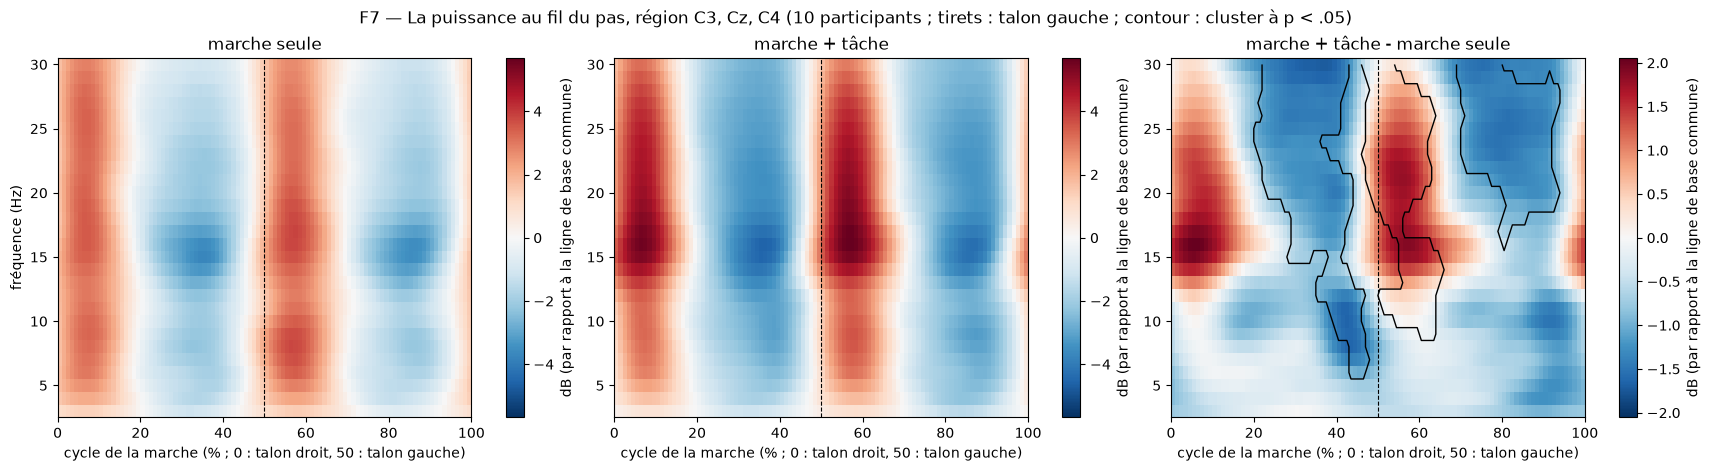

Niveau, 13-25 Hz, marche + tâche - marche seule : +0.02 dB, t(9) = 0.03, p = 0.976
Modulation par le pas (RMS, 3-30 Hz) : marche seule 2.03 dB, marche + tâche 2.76 dB ; différence +0.72 dB, t(9) = 2.75, p = 0.022 ; plus forte avec la tâche chez 8 participants sur 10
cluster : 6-30 Hz, 20-47 % du cycle, puissance plus faible avec la tâche, p = 0.012
cluster : 9-30 Hz, 46-65 % du cycle, puissance plus forte avec la tâche, p = 0.031
cluster : 16-30 Hz, 69-93 % du cycle, puissance plus faible avec la tâche, p = 0.033


In [20]:
# ---- F7 (Bloc Type 3) Les cartes du cycle de la marche, et les tests -------------------------------------------------------------
from mne.stats import permutation_cluster_1samp_test
seule = np.array([cartes_marche[(p, 'marche seule')] for p in marcheurs])   # participants x fréquences x phases (dB)
tache = np.array([cartes_marche[(p, 'marche + tâche')] for p in marcheurs])
B = (seule.mean(axis=2) + tache.mean(axis=2)) / 2            # la ligne de base commune de chaque participant : fréquences
difference = tache - seule                                   # B disparaît : le rapport des deux puissances (dB)
cyclique = difference - difference.mean(axis=2, keepdims=True)   # la partie de la différence qui suit le pas


def modulation(c):
    """RMS (dB) de chaque carte autour de sa moyenne sur le cycle : combien la puissance suit le pas."""
    return np.sqrt(((c - c.mean(axis=2, keepdims=True)) ** 2).mean(axis=(1, 2)))


t_obs, clusters, p_clusters, _ = permutation_cluster_1samp_test(cyclique, threshold=stats.t.ppf(0.975, len(marcheurs) - 1),
                                                                n_permutations=min(2 ** len(marcheurs), 1024), seed=1, out_type='mask')
phases = np.arange(N_PHASE)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
lim = np.abs(np.concatenate([(seule - B[:, :, None]).mean(axis=0), (tache - B[:, :, None]).mean(axis=0)])).max()
panneaux = [('marche seule', (seule - B[:, :, None]).mean(axis=0), lim), ('marche + tâche', (tache - B[:, :, None]).mean(axis=0), lim),
            ('marche + tâche - marche seule', difference.mean(axis=0), np.abs(difference.mean(axis=0)).max())]
for ax, (titre, carte_, l_) in zip(axes, panneaux):
    image = ax.imshow(carte_, aspect='auto', origin='lower', cmap='RdBu_r', vmin=-l_, vmax=l_,
                      extent=[0, 100, FREQUENCES[0] - 0.5, FREQUENCES[-1] + 0.5])
    ax.axvline(50, color='k', lw=0.8, ls='--')               # le contact du talon gauche
    ax.set_title(titre)
    ax.set_xlabel('cycle de la marche (% ; 0 : talon droit, 50 : talon gauche)')
    fig.colorbar(image, ax=ax, label='dB (par rapport à la ligne de base commune)')
for masque, p_ in zip(clusters, p_clusters):                 # les clusters à p < .05 : un contour
    if p_ < 0.05:
        axes[2].contour(phases + 0.5, FREQUENCES, masque.astype(float), levels=[0.5], colors='k', linewidths=1)
axes[0].set_ylabel('fréquence (Hz)')
fig.suptitle(f'F7 — La puissance au fil du pas, région {", ".join(REGION)} ({len(marcheurs)} participants ; tirets : talon gauche ; '
             'contour : cluster à p < .05)')
plt.show()

dans_bande_tf = (FREQUENCES >= BANDE[0]) & (FREQUENCES <= BANDE[1])
niveau = difference[:, dans_bande_tf].mean(axis=(1, 2))     # la différence moyenne sur le cycle, dans votre bande (dB)
t, p = stats.ttest_1samp(niveau, 0.0)
print(f'Niveau, {BANDE[0]}-{BANDE[1]} Hz, marche + tâche - marche seule : {niveau.mean():+.2f} dB, t({len(niveau) - 1}) = {t:.2f}, p = {p:.3f}')
bilan[f'5.3 niveau {BANDE[0]}-{BANDE[1]} Hz ({", ".join(REGION)}) : marche + tâche - marche seule (dB)'] = dict(
    n=len(niveau), difference_moyenne=round(niveau.mean(), 2), t=round(t, 2), p=round(p, 4))
m_seule, m_tache = modulation(seule), modulation(tache)
t, p = stats.ttest_rel(m_tache, m_seule)
print(f'Modulation par le pas (RMS, 3-30 Hz) : marche seule {m_seule.mean():.2f} dB, marche + tâche {m_tache.mean():.2f} dB ; '
      f'différence {(m_tache - m_seule).mean():+.2f} dB, t({len(m_seule) - 1}) = {t:.2f}, p = {p:.3f} ; '
      f'plus forte avec la tâche chez {int((m_tache > m_seule).sum())} participants sur {len(m_seule)}')
bilan[f'5.3 modulation par le pas ({", ".join(REGION)}) : marche + tâche - marche seule (dB)'] = dict(
    n=len(m_seule), difference_moyenne=round((m_tache - m_seule).mean(), 2), t=round(t, 2), p=round(p, 4))
for masque, p_ in sorted(zip(clusters, p_clusters), key=lambda x: x[1])[:3]:   # les trois clusters les plus nets
    f_, ph_ = np.nonzero(masque)
    signe = 'plus forte' if t_obs[masque].mean() > 0 else 'plus faible'
    print(f'cluster : {FREQUENCES[f_].min()}-{FREQUENCES[f_].max()} Hz, {ph_.min()}-{ph_.max()} % du cycle, '
          f'puissance {signe} avec la tâche, p = {p_:.3f}')

**Que regarder ? (F7)** Dans les deux conditions, la puissance suit le pas : elle monte à toutes les fréquences juste après chaque contact
du talon (0 à 15 % et 50 à 65 % du cycle) et baisse entre les deux. Avec la tâche, cette forme est plus marquée : dans la région du bêta
central, la modulation passe de 2,03 à 2,76 dB (+0,72 dB, p = .022, plus forte chez 8 participants sur 10). La carte de droite garde la
même forme : plus de puissance après le contact du talon gauche, moins entre les contacts (trois clusters, p = .012 à .033). Le niveau,
lui, ne change pas (+0,02 dB dans le bêta, p = .98) : la tâche ne change pas la puissance pendant la marche, seulement sa façon de suivre
le pas. Les deux autres régions vont dans le même sens (thêta frontal : +0,55 dB, p = .047 ; alpha postérieur : +0,52 dB, p = .067).

La marche seule a environ trois fois moins de foulées que les quatre blocs. Une moyenne de moins de foulées garde plus de bruit, ce qui
gonfle sa modulation : ce biais va contre le résultat.

**D'où vient cette modulation ?** Une hausse à toutes les fréquences, dans toutes les régions, calée sur le contact du talon : c'est la
signature des artefacts de mouvement, qui changent d'une personne et d'une électrode à l'autre (Kline et al., 2015). La tâche change
peut-être la façon dont la tête et le corps bougent à chaque pas. Une activité du cerveau calée sur le cycle de la marche existe aussi (Gwin
et al., 2011), mais avec 19 électrodes sèches, ces données ne permettent pas de séparer les deux.

### 5.4 Le repos du début et le repos de la fin (Bloc Type 3)

Les deux repos sont le même enregistrement, à environ une heure d'écart. La différence fin - début, pour votre mesure, avec les électrodes
mesurées dans les deux repos, et selon l'ordre de la séance.

In [21]:
# ---- 5.4 (Bloc Type 3) Le repos de la fin moins le repos du début ----------------------------------------------------------------
lignes = []
for participant in sorted({p for p, _ in continus}):
    infos = enregistrements[enregistrements['participant'] == participant].set_index('enregistrement')
    if not {'repos_debut', 'repos_fin'} <= set(infos.index):
        continue
    s = {nom: spectre_sans_tache(continus[(participant, nom)], infos.loc[nom, 'reconstruites'])[0] for nom in ('repos_debut', 'repos_fin')}
    k = [noms_ch.index(c) for c in REGION if all(np.isfinite(s[nom][noms_ch.index(c)]).all() for nom in s)]   # mesurées dans les deux
    if not k:
        continue
    db_ = {nom: 10 * np.log10(s[nom][k][:, dans_bande].mean()) for nom in s}
    lignes.append({'participant': participant, 'ordre': infos['ordre'].iloc[0], 'début (dB)': db_['repos_debut'],
                   'fin (dB)': db_['repos_fin'], 'fin - début (dB)': db_['repos_fin'] - db_['repos_debut']})
repos_2 = pd.DataFrame(lignes).set_index('participant')
t, p = stats.ttest_1samp(repos_2['fin - début (dB)'], 0.0)
print(f'{NOM}, fin - début : {repos_2["fin - début (dB)"].mean():+.2f} dB, t({len(repos_2) - 1}) = {t:.2f}, p = {p:.3f} ; '
      f'{int((repos_2["fin - début (dB)"] > 0).sum())} sur {len(repos_2)} au-dessus de 0')
print('Selon l\'ordre de la séance :', repos_2.groupby('ordre')['fin - début (dB)'].mean().round(2).to_dict())
bilan[f'5.4 {NOM}, repos fin - début (dB)'] = dict(n=len(repos_2), difference_moyenne=round(repos_2['fin - début (dB)'].mean(), 2),
                                                 t=round(t, 2), p=round(p, 4))
repos_2.round(2)

bêta central, fin - début : +0.19 dB, t(8) = 0.37, p = 0.722 ; 4 sur 9 au-dessus de 0
Selon l'ordre de la séance : {"assis d'abord": 0.22, "marche d'abord": 0.14}


,ordre,début (dB),fin (dB),fin - début (dB)
participant,,,,
P002,marche d'abord,-2.72,-3.11,-0.39
P003,assis d'abord,-3.90,-4.76,-0.85
P004,assis d'abord,-1.19,0.19,1.38
P006,marche d'abord,-3.48,-4.48,-1.00
P007,assis d'abord,-2.71,-2.39,0.32
P008,assis d'abord,-0.14,-0.90,-0.76
P009,marche d'abord,-1.06,-2.47,-1.41
P010,marche d'abord,-5.34,-1.96,3.38
P012,assis d'abord,-2.08,-1.05,1.03


**Que regarder ? (5.4)** Pour le bêta central, les deux repos se ressemblent (+0,19 dB, p = .72). Avec `MESURE = 'thêta frontal'`, le
thêta baisse du début à la fin chez 7 participants sur 9 (-1,07 dB, p = .071), dans les deux ordres de la séance. Le temps passé sur la
tâche peut l'expliquer. Les électrodes sèches aussi : leur contact avec la peau change pendant la séance, et avec lui le bruit des basses
fréquences. C'est une raison de prendre, en 5.2, le repos voisin des blocs assis.

## 6. Synthèse (Bloc Type 1)

Le tableau réunit tous les tests faits avec vos derniers choix. Relancez le notebook avec d'autres choix (`HYPOTHESE`, `MESURE`) pour
compléter votre tableau de résultats.

In [22]:
# ---- 6.1 Tous vos tests ----------------------------------------------------------------------------------------------------------
print(f'Hypothèse « {HYPOTHESE} » ({COND_B} - {COND_A}), {NOM} : {BANDE[0]} à {BANDE[1]} Hz, {FENETRE[0] * 1000:.0f} à '
      f'{FENETRE[1] * 1000:.0f} ms, région {", ".join(REGION)}')
pd.DataFrame.from_dict(bilan, orient='index')                # une ligne par test

Hypothèse « posture » (marche - assis), bêta central : 13 à 25 Hz, 300 à 800 ms, région C3, Cz, C4


,n,difference_moyenne,t,p,dz,electrodes
"F2 puissance absolue (dB) (13-25 Hz, C3, Cz, C4) : marche - assis",8,5.92,4.93,0.0017,1.74,NaN
"F2 puissance relative (%) (13-25 Hz, C3, Cz, C4) : marche - assis",8,-5.08,-1.83,0.1107,-0.65,NaN
"2.2 bêta central, avant le mot (dB)",8,5.25,4.44,0.0030,NaN,NaN
"2.2 bêta central, changement (dB)",8,1.06,2.98,0.0205,NaN,NaN
"2.2 bêta central, changement (µV²)",8,24.12,2.73,0.0292,NaN,NaN
F4 bêta central : marche - assis,8,1.06,2.98,0.0205,1.05,NaN
F5 électrodes à p < .05 (bêta central),8,NaN,NaN,NaN,NaN,"C3, Cz"
"5.2 bêta central, tâche assis - repos (dB)",8,-0.58,-0.94,0.3796,NaN,NaN
"5.2 bêta central, tâche en marche - marche seule (dB)",8,0.20,0.29,0.7767,NaN,NaN
"5.2 bêta central, marche seule - repos (dB)",8,5.04,3.40,0.0115,NaN,NaN


**Pour votre rapport.**
1. Énoncez votre hypothèse et vos prédictions (la mesure, le sens de l'effet) *avant* de présenter les résultats.
2. Pour chaque test, rapportez la moyenne de chaque condition, la différence, t(ddl), p et dz, et le nombre de participants.
3. Décrivez F1 et F3 : quelles fréquences changent, quand, et dans quelle posture ?
4. Pour la posture, rapportez la puissance avant le mot et le changement en dB et en µV² (2.2) : la conclusion dépend-elle de la mesure ?
5. Discutez les limites : le petit nombre de participants, le bruit de la marche, le filtre sous 30 Hz, les tests non corrigés de F5.

<details><summary>Indices</summary>

Avec l'hypothèse `'posture'`, la baisse de l'alpha et du bêta et la hausse du thêta sont plus petites en marche. Pour le bêta central, la
différence est significative en dB (p = .021) comme en µV² (p = .029) ; pour le thêta frontal, en dB seulement (p = .045). Avec `'frequence'` et `'lexicalite'`, les différences du thêta frontal
sont petites et non significatives (p = .16 et p = .29).
</details>

**Le notebook suivant.** Le notebook 11 se sert de ces bandes, et des ERP du notebook 09, pour prédire la condition d'un essai seul
(apprentissage machine).

### Références

- Cavanagh, J. F., & Frank, M. J. (2014). Frontal theta as a mechanism for cognitive control. *Trends in Cognitive Sciences, 18*, 414-421. https://doi.org/10.1016/j.tics.2014.04.012
- Cohen, M. X. (2019). A better way to define and describe Morlet wavelets for time-frequency analysis. *NeuroImage, 199*, 81-86. https://doi.org/10.1016/j.neuroimage.2019.05.048
- Gwin, J. T., Gramann, K., Makeig, S., & Ferris, D. P. (2011). Electrocortical activity is coupled to gait cycle phase during treadmill walking. *NeuroImage, 54*, 1289-1296. https://doi.org/10.1016/j.neuroimage.2010.08.066
- Gyurkovics, M., Clements, G. M., Low, K. A., Fabiani, M., & Gratton, G. (2021). The impact of 1/f activity and baseline correction on the results and interpretation of time-frequency analyses of EEG/MEG data: A cautionary tale. *NeuroImage, 237*, 118192. https://doi.org/10.1016/j.neuroimage.2021.118192
- Keil, A., Bernat, E. M., Cohen, M. X., Ding, M., Fabiani, M., Gratton, G., Kappenman, E. S., Maris, E., Mathewson, K. E., Ward, R. T., & Weisz, N. (2022). Recommendations and publication guidelines for studies using frequency domain and time-frequency domain analyses of neural time series. *Psychophysiology, 59*, e14052. https://doi.org/10.1111/psyp.14052
- Kline, J. E., Huang, H. J., Snyder, K. L., & Ferris, D. P. (2015). Isolating gait-related movement artifacts in electroencephalography during human walking. *Journal of Neural Engineering, 12*, 046022. https://doi.org/10.1088/1741-2560/12/4/046022
- Peskar, M., Omejc, N., Šömen, M. M., Miladinović, A., Gramann, K., & Marusic, U. (2023). Stroop in motion: Neurodynamic modulation underlying interference control while sitting, standing, and walking. *Biological Psychology, 178*, 108543. https://doi.org/10.1016/j.biopsycho.2023.108543
- Pfurtscheller, G., & Lopes da Silva, F. H. (1999). Event-related EEG/MEG synchronization and desynchronization: Basic principles. *Clinical Neurophysiology, 110*, 1842-1857. https://doi.org/10.1016/S1388-2457(99)00141-8
- Protzak, J., & Gramann, K. (2021). EEG beta-modulations reflect age-specific motor resource allocation during dual-task walking. *Scientific Reports, 11*, 16110. https://doi.org/10.1038/s41598-021-94874-2
- Reiser, J. E., Wascher, E., & Arnau, S. (2019). Recording mobile EEG in an outdoor environment reveals cognitive-motor interference dependent on movement complexity. *Scientific Reports, 9*, 13086. https://doi.org/10.1038/s41598-019-49503-4
- Seeber, M., Scherer, R., Wagner, J., Solis-Escalante, T., & Müller-Putz, G. R. (2014). EEG beta suppression and low gamma modulation are different elements of human upright walking. *Frontiers in Human Neuroscience, 8*, 485. https://doi.org/10.3389/fnhum.2014.00485